# QA/QC of historical runs

Once bias-corrected and downscaled, historical simulations should perform well in high level performance statsitics calculated against the training dataset (in our case, ERA5). They will still not match in more detailed comparisons. This notebook will perform some standard evaluations to understand how a dataset compares against ERA5, as well as another comparison dataset (e.g. a previous version of a downscaled dataset).

Use cases of this notebook:
- you've run the downscaling code and want to see how the results compare to ERA5
- you've run a new version of the downscaling code and want to see how the results compare to the earlier version, with the context of the  ERA5 and the raw input GCM

In [46]:
%load_ext autoreload
%autoreload 2
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterix
import seaborn as sns
import xarray as xr
from ibicus.debias import QuantileMapping
from rasterix.rasterize.rasterio import geometry_clip

from srm import catalog
from srm.utils import icechunk_store_to_dataset, clean_up_dataset, convert_precip_units
from srm.plotting import (plot_comparisons, calculate_statistic_to_plot, prep_datasets_for_daily_timeseries_plotting, 
            prep_datasets_for_seasonal_cycle_plotting, plot_timeseries, sel_point, plot_pdf)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load in dataset you want to inspect

In [30]:
ds1 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_nonparametric.nc', engine='h5netcdf')
ds2 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_parametric.nc', engine='h5netcdf')

## Load in ERA5 and raw GCM for comparison

In [31]:
variables = ['pr']

In [32]:
era5 = icechunk_store_to_dataset("ERA5", catalog)
era5 = clean_up_dataset(era5, "ERA5")[variables]

## Maps
Make plots comparing maps of some high level statistics

In [33]:
# Trim the comparison datasets to the same spatial extent 

In [34]:
gcm = "CESM2-WACCM" # TODO - once dataset name is fixed this should update to CESM2
scenario = "Historical"# "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
ensemble_member='007'
# TODO: make the training period an attr in the dataset
training_period = slice("1978-01-01", "2014-12-31") 
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.longitude.max().values, ds1.longitude.min().values
lat_max, lat_min = ds1.latitude.max().values, ds1.latitude.min().values

In [35]:
raw = icechunk_store_to_dataset(dataset_name, catalog)

In [36]:
raw = clean_up_dataset(raw, gcm)[variables]

In [37]:
# for this set-up we'll convert precip units to all be on mm/day
ds1 = convert_precip_units(ds1, 'ERA5')
ds1 = ds1.drop('spatial_ref')
if ds2 is not None:
    ds2 = convert_precip_units(ds2, 'ERA5')
    ds2 = ds2.drop('spatial_ref')

/tmp/ipykernel_13727/4216431243.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds1 = ds1.drop('spatial_ref')
/tmp/ipykernel_13727/4216431243.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds2 = ds2.drop('spatial_ref')


### Subset to the training period for an appropriate comparison

For the historical period we'll want to analyze the observations and the raw simulations only for the training period. For those periods basic metrics should match extremely well (by definition). We'll then evaluate other time periods and other more complicated metrics.

In [38]:
variable=variables[0]

In [39]:
raw = raw.sel(time=training_period, 
              latitude=slice(lat_min, lat_max), 
              longitude=slice(lon_min, lon_max))
era5 = era5.sel(time=training_period, 
              latitude=slice(lat_min, lat_max), 
              longitude=slice(lon_min, lon_max))
ds1 = ds1.sel(time=training_period)
ds2 = ds2.sel(time=training_period)

## Maps

We'll use maps to see how spatial patterns and high level statistics are matching between ERA5 and the downscaled/bias-corrected simulations. We'll then also compare the differences between the 

In [ ]:
# brendan TODO: add routines to `calculate_statistic_to_plot` so that it calculates the following extremes. it may be useful to use a package like 
# xclim (or similar) to calculate these (if you need help installing it let us know!)
# - 99%-ile precipitation
# - days over 30 degrees c
# - average hottest day of the year
# - dry day fraction
# - growing degree days
# brendan TODO: rerun the `calculate_statistic_to_plot` and `plot_comparisons` for each of the statistics you calculated above so that we have a 

In [12]:
# team TODO: remove this temporal subsetting *once this notebook development complete* (i.e. when merging into main). 
# i include it now because while in development, it's helpful to subset to a single year to 
# speed up the processing and make it easier to run repeatedly 
raw_toplot, era5_toplot, ds1_toplot, ds2_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1.isel(time=slice(0, 365)),
                                                                              'mean',
                                                                              'pr',
                                                                              ds2=ds2.isel(time=slice(0, 365)))

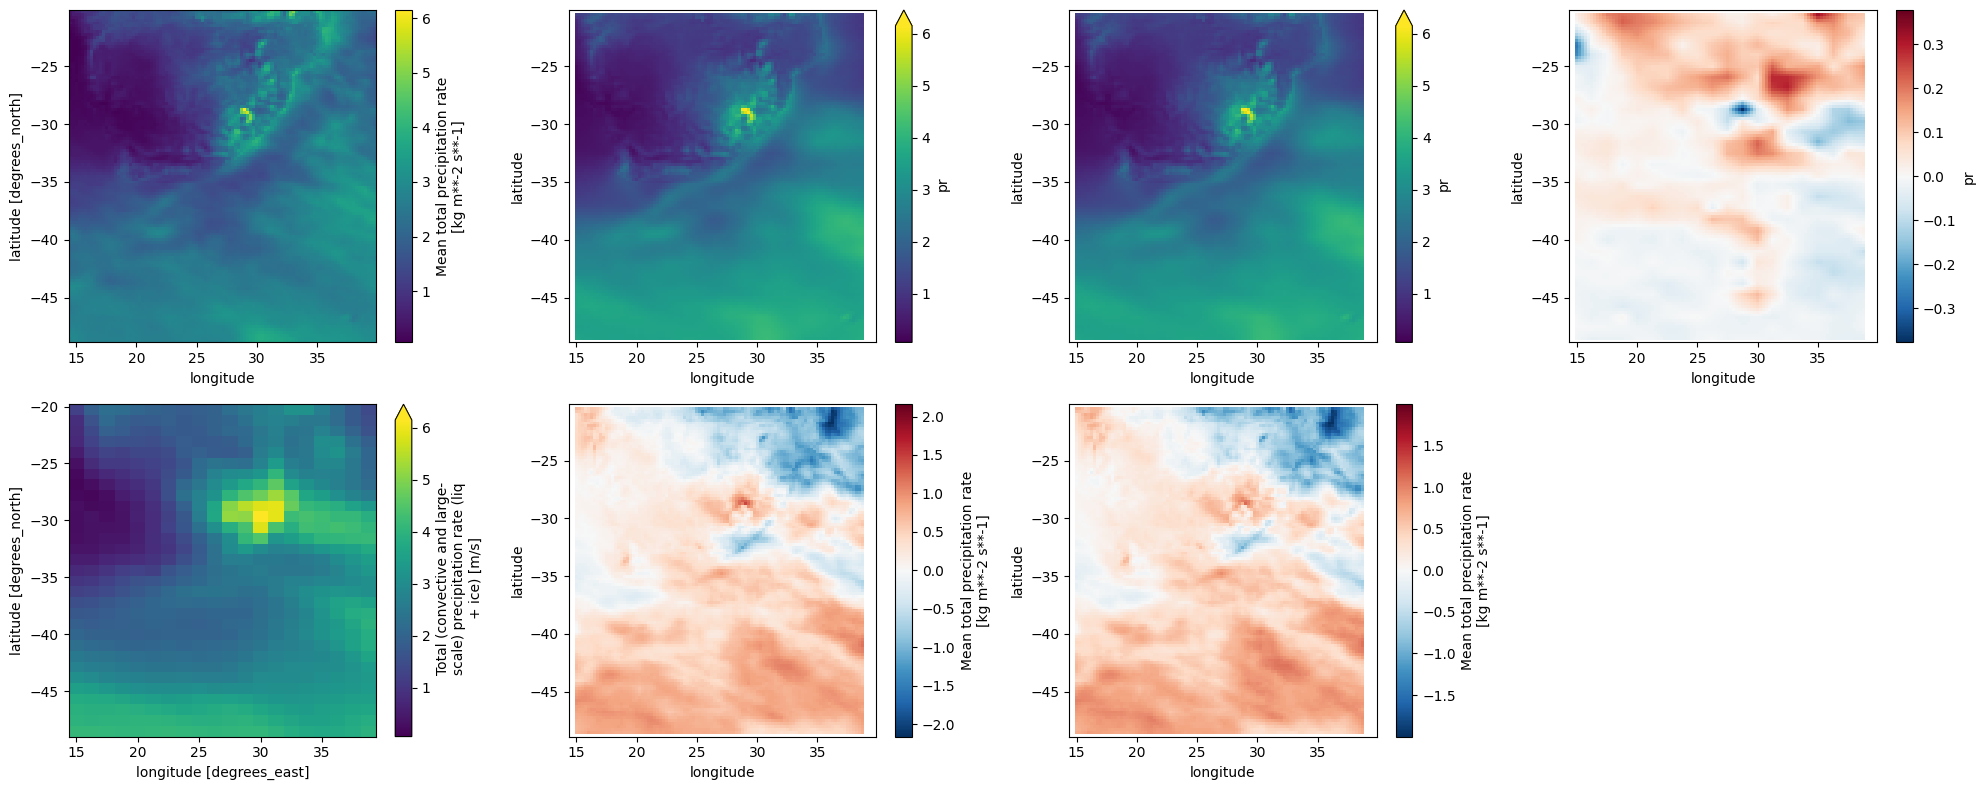

In [13]:
# brendan TODO: add a title to the figure that includes variable, statistic, time period (any other relevant information?).
# brendan TODO: add a title to each panel so we know which is which (e.g. first panel is "Raw GCM"
plot_comparisons(era5_toplot, raw_toplot, ds1_toplot, ds2_toplot) 

## Location selection for timeseries and CDF analysis

First we need to choose the locations we want to look at. Let's pick:
- 10 major cities around the world from a variety of zones
- A locations from each Koppen-Geiger zone (or some other set of locations that allows us to sample different climatic zones). This will be our way of selecting locations that have different climatic regimes (e.g. monsoons, cold climates, tropical, strong seasonal cycles, weak seasonal cycles, etc.). By choosing a range of locations we'll get a better handle on corner cases of where the model might be going haywire.

In [13]:
locations = {'Cape Town': (-33.9221, 18.4231),
            # TODO Temi: add in 9 more major cities around the world
            # TODO Temi: add in 10 locations from a variety of climatic zones around the world
            }

## Seasonal cycle timeseries

In [ ]:
# temi TODO: write a description here for why we're doing this kind of analysis

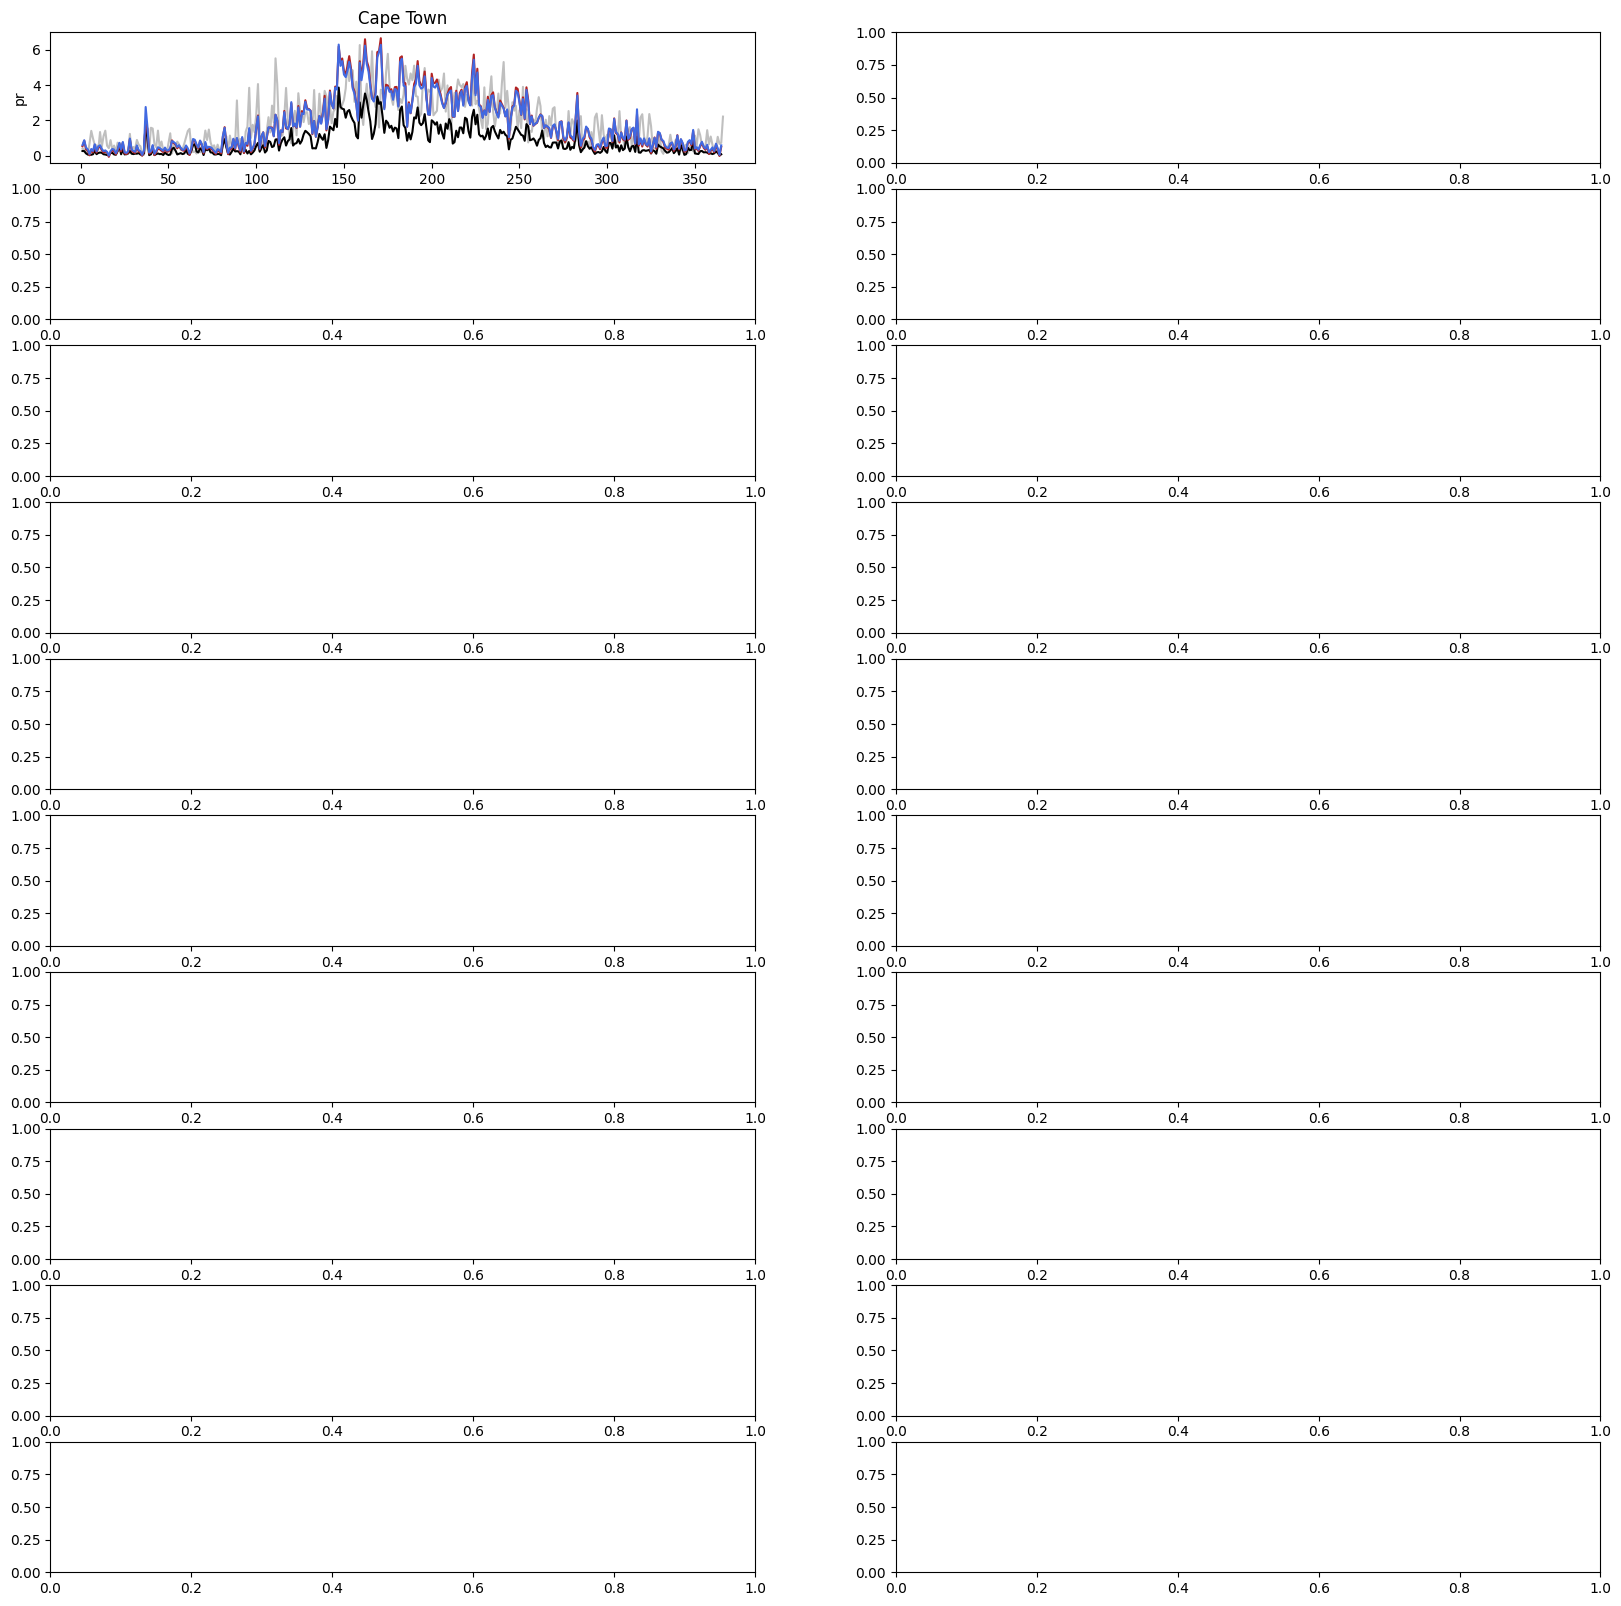

In [28]:
# temi TODO: add three more cells in this notebook, repeating these seasonal cycle plots for tasmax, tasmin, and tas 
variable = 'pr'
time_slice = slice('1984', '2014')

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20,20))
axarr = axarr_shape.flatten()
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_seasonal_cycle_plotting(era5, raw, ds1, 
                                                                                            time_slice, lat, 
                                                                                            lon, variable, ds2=ds2)

    plot_timeseries(axarr[i], era5_toplot, raw_toplot, ds1_toplot, location, ds2_toplot)
    axarr[i].set_title(location)
    # temi TODO: add a single legend applying to all of the panels of plots, above the figure
    # temi TODO: add a title at the top of this figure (as part of the function) describing the variable and time period
    # temi TODO: fix ylabels to have units

## Daily timeseries

These plots will be the closest we'll get to looking at actual data - daily timeseries for individual locations.

In [ ]:
# Make a figure with all of the timeseries for all of the locations for the same time slice
# Repeat for a randomly selected year - for ease of calendar use only choose non-leap year calendars

In [ ]:
ds_list = [era5, raw, ds1, ds2]


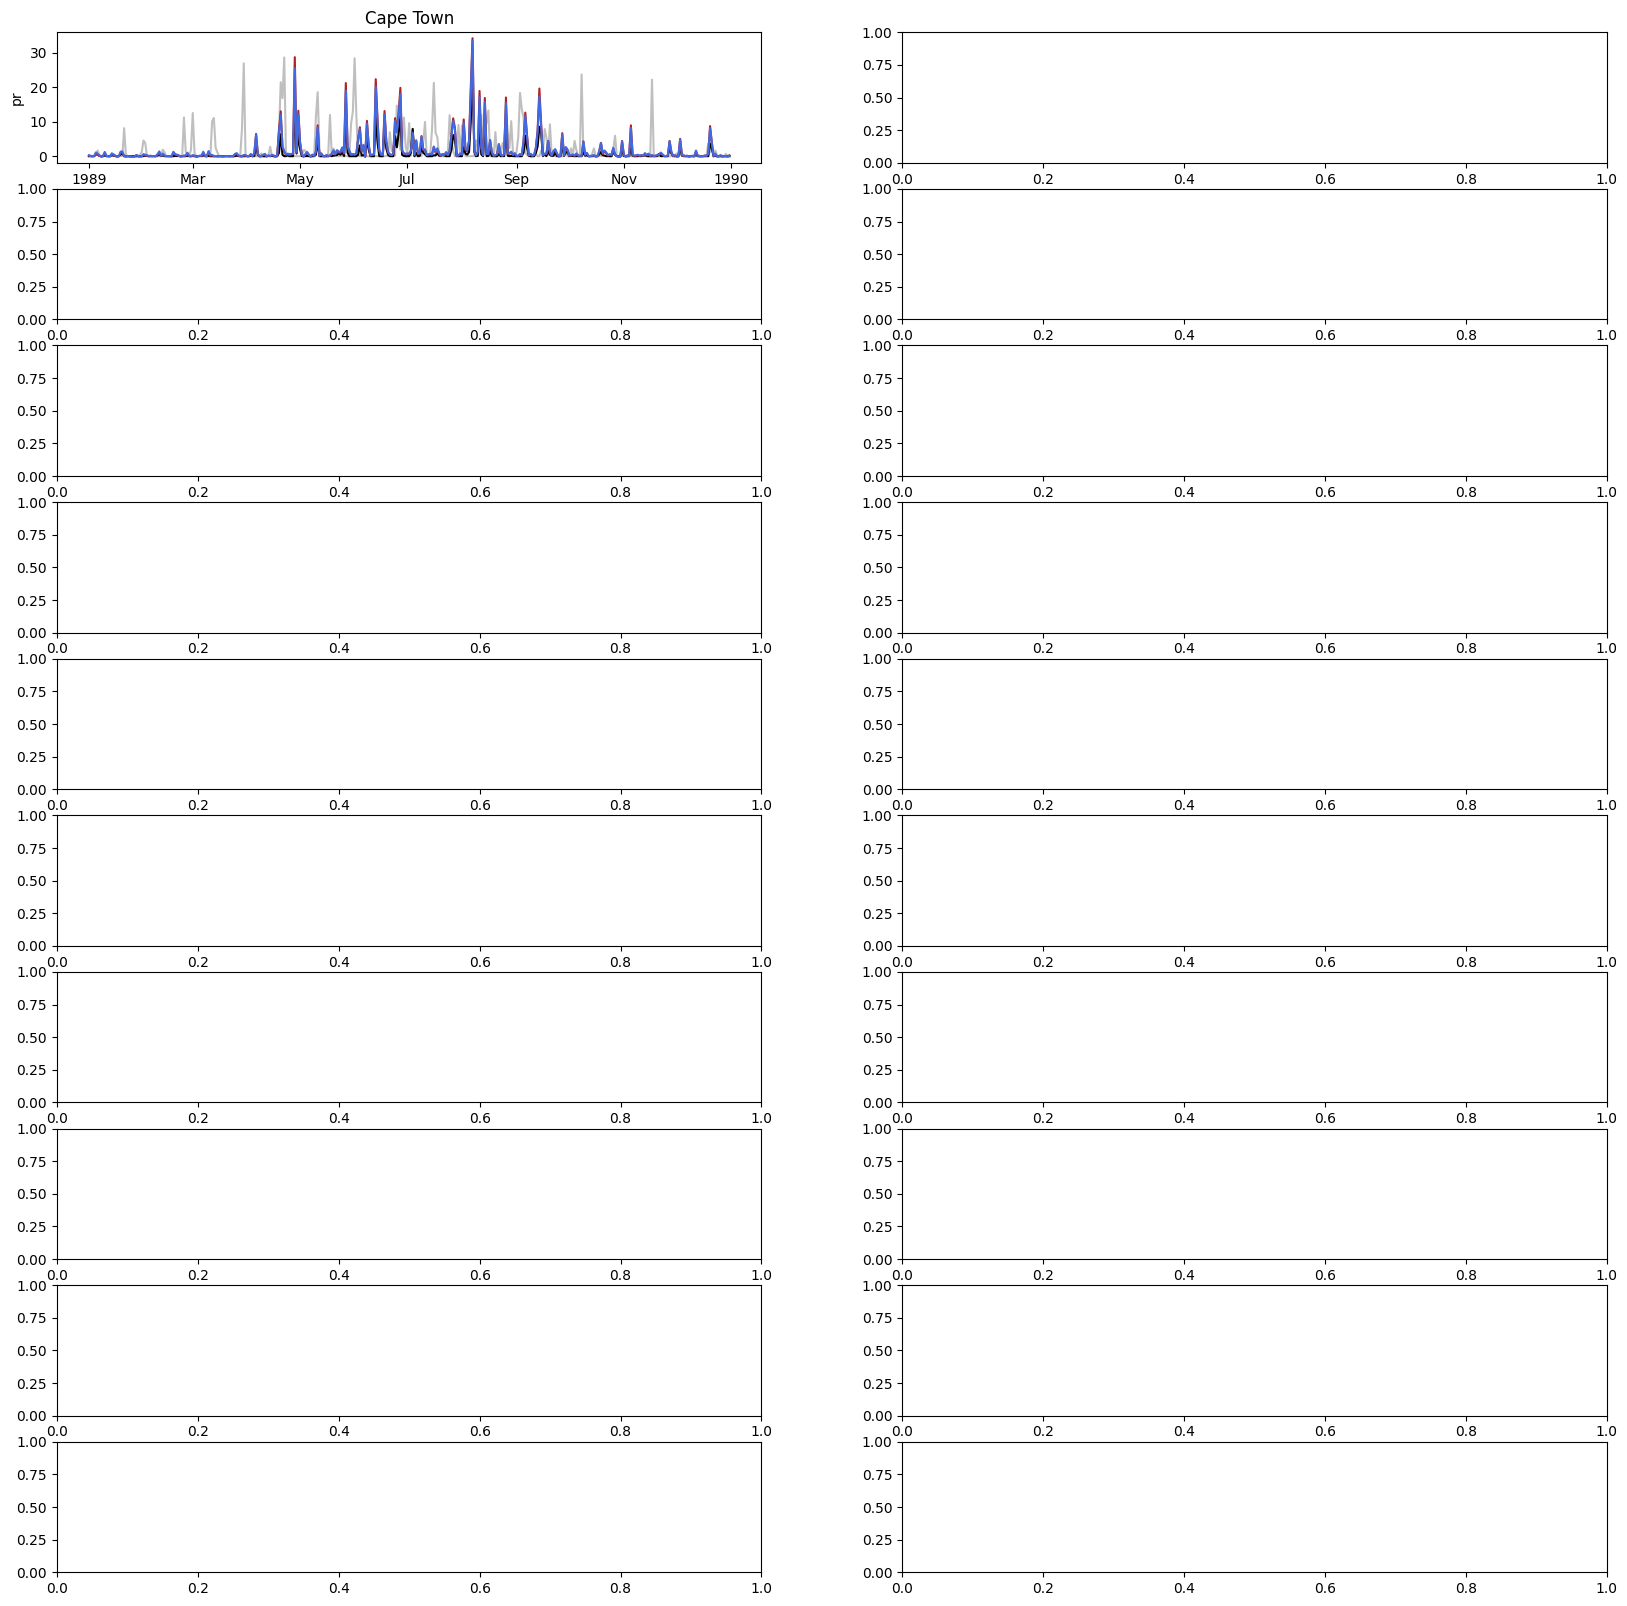

In [26]:
# temi TODO: add three more cells in this notebook, repeating these daily timeseries plots for tasmax, tasmin, and tas 
variable = 'pr'
time_slice = slice('1989', '1989')

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20,20))
axarr = axarr_shape.flatten()
# temi TODO: rerun this cell when the locations dict above has 20 locations in it
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_daily_timeseries_plotting(era5, raw, ds1, 
                                                                                            time_slice, lat, 
                                                                                            lon, ds2=ds2)
    era5_toplot[variable].plot(ax=axarr[i], color='grey', alpha=0.5)
    raw_toplot[variable].plot(ax=axarr[i], color='k')
    ds1_toplot[variable].plot(ax=axarr[i], color='firebrick')
    ds2_toplot[variable].plot(ax=axarr[i], color='royalblue')   
    axarr[i].set_title(location)

    # temi TODO: add a single legend applying to all of the panels of plots, above the figure
    # temi TODO: fix ylabels to have units

## Distribution analyses

In [56]:
era5_toplot = sel_point(era5, lat, lon)[variable]
raw_toplot = sel_point(raw, lat, lon)[variable]
ds1_toplot = sel_point(ds1, lat, lon)[variable]
ds2_toplot = sel_point(ds2, lat, lon)[variable]

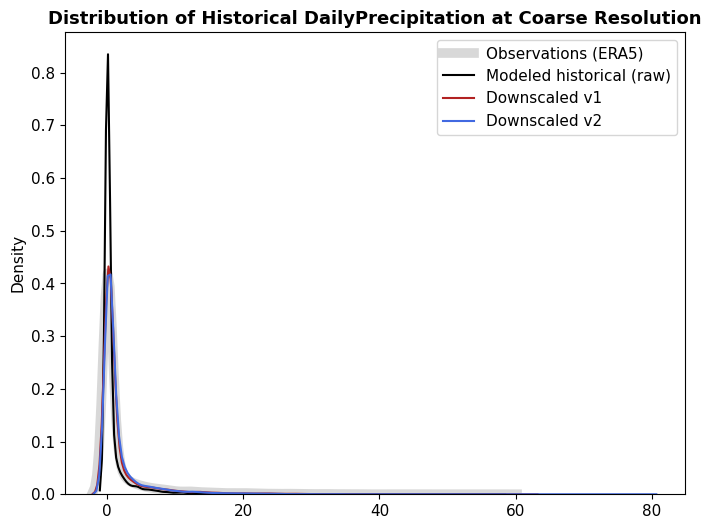

In [67]:
# temi TODO: make a function which create a 20-panel plot like the timeseries above, but each panel is the PDF below.
plot_pdf(era5_toplot, raw_toplot, ds1_toplot, 'pr', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Precipitation at Coarse Resolution")

In [ ]:
# temi TODO: repeat the PDF figures (and update/extend the `plot_pdf` function as needed) for tasmax, tasmin, tas 

In [ ]:
# brendan TODO: create a figure using the same styles as the PDFs, but as a CDF.
# brendan TODO: add a cell to this notebook with a couple of sentences explaining how 
# CDFs and PDFs are good for different things